0: ─╭AngleEmbedding(M0)─╭BasicEntanglerLayers(M1)─╭AngleEmbedding(M2)†─┤ ╭<|0000⟩⟨0000|>
1: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─├AngleEmbedding(M2)†─┤ ├<|0000⟩⟨0000|>
2: ─├AngleEmbedding(M0)─├BasicEntanglerLayers(M1)─├AngleEmbedding(M2)†─┤ ├<|0000⟩⟨0000|>
3: ─╰AngleEmbedding(M0)─╰BasicEntanglerLayers(M1)─╰AngleEmbedding(M2)†─┤ ╰<|0000⟩⟨0000|>

M0 = 
[0.49007124 0.18247505 2.72117262 1.8884585 ]
M1 = 
[[0. 0. 0. 0.]]
M2 = 
[2.22447561 0.0646681  3.04706167 2.61519568]


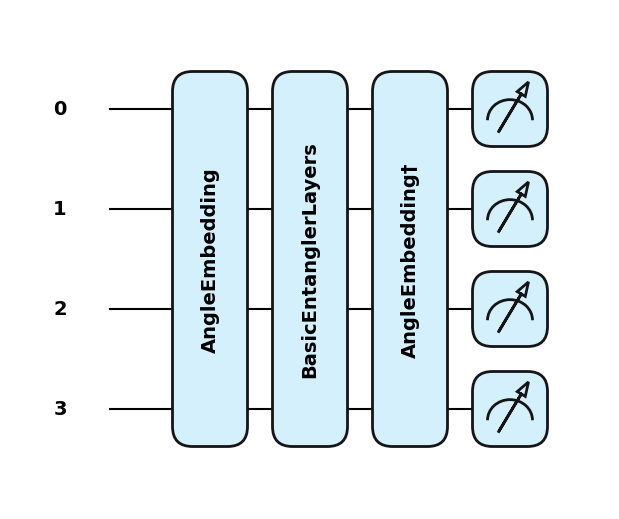

In [3]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

n_qubits = 4  # reduzir para visualização
x1_example = np.random.uniform(0, np.pi, n_qubits)
x2_example = np.random.uniform(0, np.pi, n_qubits)

dev_draw = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_draw)
def kernel_draw(x1, x2):
    qml.AngleEmbedding(x1, wires=range(n_qubits), rotation="X")
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, n_qubits)),
        wires=range(n_qubits),
        rotation=qml.RZ
    )
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(n_qubits), rotation="Y")
    return qml.expval(qml.Projector([0] * n_qubits, wires=range(n_qubits)))

print(qml.draw(kernel_draw)(x1_example, x2_example))
fig, ax = qml.draw_mpl(kernel_draw, style="pennylane")(x1_example, x2_example)
plt.savefig("angle_embedding_full.png", dpi=160, bbox_inches='tight')
plt.show()

/tmp/ipykernel_26359/2569841457.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


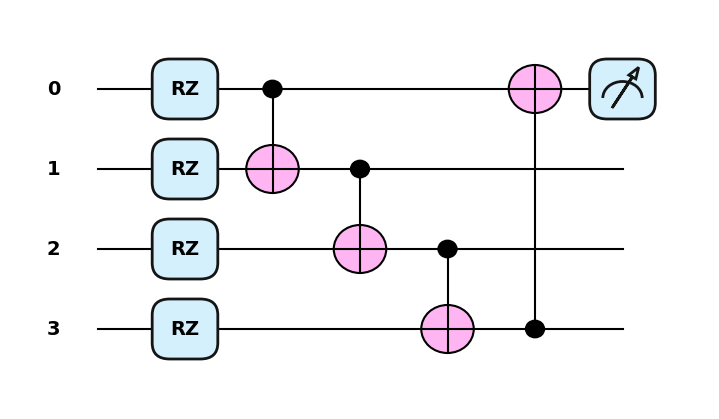

In [4]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def entangler_circuit():
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, n_qubits)),
        wires=range(n_qubits),
        rotation=qml.RZ
    )
    return qml.expval(qml.PauliZ(0))

fig, ax = qml.draw_mpl(
    entangler_circuit,
    style="pennylane",
    wire_order=list(range(n_qubits)),
    show_all_wires=True,
    level="device",   # <-- expande em RZ + CNOT
)()

fig.set_size_inches(7, 4)
plt.tight_layout()
plt.savefig("basic_entangler_layers.png", dpi=160, bbox_inches='tight')
plt.show()

/tmp/ipykernel_26359/2308808238.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


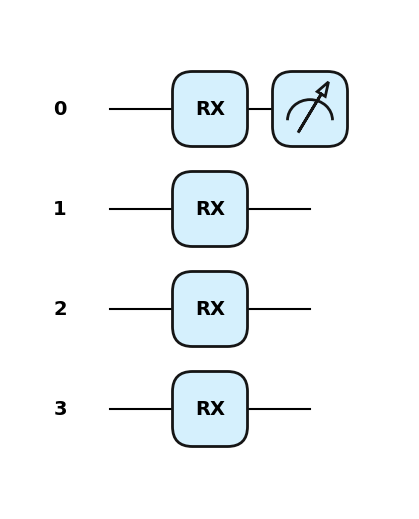

In [5]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

n_qubits = 4
np.random.seed(42)
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def angle_circuit():
    qml.AngleEmbedding(x_example, wires=range(n_qubits), rotation="X")
    return qml.expval(qml.PauliZ(0))

fig, ax = qml.draw_mpl(
    angle_circuit,
    style="pennylane",
    wire_order=list(range(n_qubits)),
    show_all_wires=True,
    level="device",  # <-- expande em RX individuais
)()

fig.set_size_inches(4, 5)
plt.tight_layout()
plt.savefig("angle_embedding.png", dpi=160, bbox_inches='tight')
plt.show()

/tmp/ipykernel_26359/3321173176.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


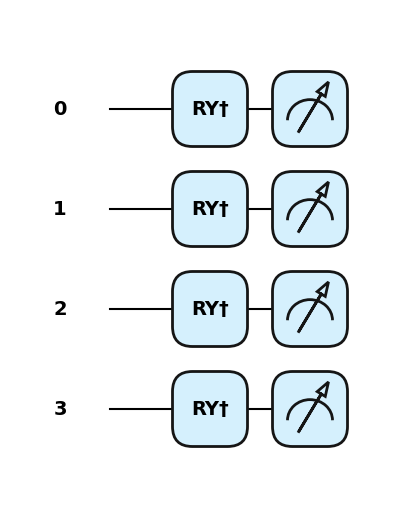

In [6]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

n_qubits = 4
np.random.seed(42)
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def angle_circuit():
    qml.adjoint(qml.AngleEmbedding)(x_example, wires=range(n_qubits), rotation="Y")
    return qml.expval(qml.Projector([0] * n_qubits, wires=range(n_qubits)))

fig, ax = qml.draw_mpl(
    angle_circuit,
    style="pennylane",
    wire_order=list(range(n_qubits)),
    show_all_wires=True,
    level="device",  # <-- expande em RX individuais
)()

fig.set_size_inches(4, 5)
plt.tight_layout()
plt.savefig("angle_embedding_adjoint.png", dpi=160, bbox_inches='tight')
plt.show()